In [1]:
%pip install PyMySQL
from sqlalchemy import create_engine, text
import ssl
import pandas as pd

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# tablas 'olist'
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]   # convertir a lista simple de strings
    
    print("Tablas en la base 'olist':")
    for t in tables:
        print("-", t)

Note: you may need to restart the kernel to use updated packages.
Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- product_category_name_translation


In [2]:
import pandas as pd

# Cargar tablas (ejemplo usando SQLAlchemy engine)
customers = pd.read_sql("SELECT * FROM olist_customers_dataset", con=engine)
orders = pd.read_sql("SELECT * FROM olist_orders_dataset", con=engine)
order_items = pd.read_sql("SELECT * FROM olist_order_items_dataset", con=engine)
order_payments = pd.read_sql("SELECT * FROM olist_order_payments_dataset", con=engine)
order_reviews = pd.read_sql("SELECT * FROM olist_order_reviews_dataset", con=engine)
products = pd.read_sql("SELECT * FROM olist_products_dataset", con=engine)
product_cat = pd.read_sql("SELECT * FROM product_category_name_translation", con=engine)
sellers = pd.read_sql("SELECT * FROM olist_sellers_dataset", con=engine)
geo = pd.read_sql("SELECT * FROM olist_geolocation_dataset", con=engine)

In [3]:
# Función para explorar rápidamente una tabla SQL:
# carga los datos, convierte fechas, muestra dimensiones, tipos, nulos, duplicados y primeras filas
def explore_table(table, n=5):
    df = pd.read_sql_query(f"SELECT * FROM `{table}`", con=engine)
    
    for col in df.columns:
        if "date" in col.lower() or "timestamp" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")
    
    print(f"Tabla: {table}")
    print("Dimensiones:", df.shape)
    print("\nTipos de datos:")
    display(df.dtypes)
    print("\nValores nulos por columna:")
    display(df.isnull().sum())
    print("\nDuplicados (filas completas):", df.duplicated().sum())
    print(f"\nPrimeras {n} filas:")
    display(df.head(n))
    
    return df

### TABLA: olist_order_items_dataset

In [4]:
# Exploramos order_items
df_order_items = explore_table("olist_order_items_dataset")

Tabla: olist_order_items_dataset
Dimensiones: (112650, 8)

Tipos de datos:


id                              int64
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


Valores nulos por columna:


id                     0
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Duplicados (filas completas): 0

Primeras 5 filas:


,id,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,112650,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79
1,112649,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72
2,112648,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
3,112647,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
4,112646,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41


### TABLA: olist_orders_dataset

In [5]:
# Exploramos orders
df_orders = explore_table("olist_orders_dataset")

Tabla: olist_orders_dataset
Dimensiones: (99441, 9)

Tipos de datos:


id                                        int64
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


Valores nulos por columna:


id                                  0
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


Duplicados (filas completas): 0

Primeras 5 filas:


,id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,5,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [7]:
# Evolución de pedidos a lo largo del tiempo
orders_over_time = df_orders.set_index('order_purchase_timestamp').resample('MS').size()
orders_over_time

order_purchase_timestamp
2016-09-01       4
2016-10-01     324
2016-11-01       0
2016-12-01       1
2017-01-01     800
2017-02-01    1780
2017-03-01    2682
2017-04-01    2404
2017-05-01    3700
2017-06-01    3245
2017-07-01    4026
2017-08-01    4331
2017-09-01    4285
2017-10-01    4631
2017-11-01    7544
2017-12-01    5673
2018-01-01    7269
2018-02-01    6728
2018-03-01    7211
2018-04-01    6939
2018-05-01    6873
2018-06-01    6167
2018-07-01    6292
2018-08-01    6512
2018-09-01      16
2018-10-01       4
Freq: MS, dtype: int64

In [9]:
# Convertimos la serie en DataFrame y renombramos columnas para mayor claridad
df_orders_over_time = orders_over_time.reset_index()
df_orders_over_time.columns = ['order_purchase_timestamp', 'total_orders']

# Mostramos las últimas 25 filas para revisar los datos más recientes
df_orders_over_time.tail(25)

,order_purchase_timestamp,total_orders
1,2016-10-01,324
2,2016-11-01,0
3,2016-12-01,1
4,2017-01-01,800
5,2017-02-01,1780
6,2017-03-01,2682
7,2017-04-01,2404
8,2017-05-01,3700
9,2017-06-01,3245
10,2017-07-01,4026


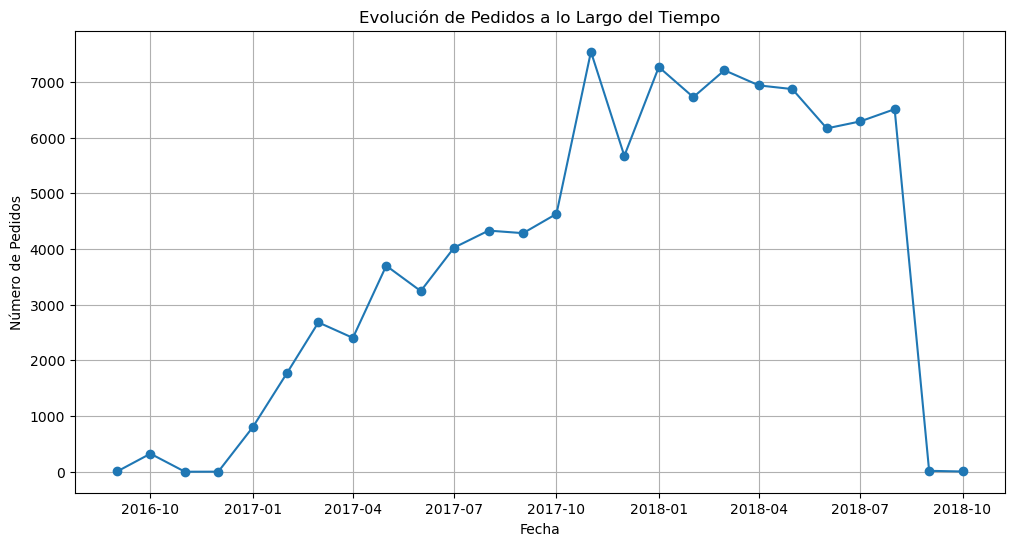

In [10]:
# Visualizamos la evolución mensual de pedidos con un gráfico de líneas
import matplotlib.pyplot as plt         
plt.figure(figsize=(12, 6))
plt.plot(orders_over_time.index, orders_over_time.values, marker='o')
plt.title('Evolución de Pedidos a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos')
plt.grid()
plt.show()

In [11]:
# Análisis del estado de los pedidos por mes: agrupamos por fecha y estado y mostramos el recuento en formato tabla
df_orders['order_status'] = df_orders['order_status'].astype('category')
orders_status_over_time = df_orders.set_index('order_purchase_timestamp').groupby([pd.Grouper(freq='MS'), 'order_status']).size().unstack(fill_value=0)
orders_status_over_time.tail(25)

/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_83342/1997299024.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_status_over_time = df_orders.set_index('order_purchase_timestamp').groupby([pd.Grouper(freq='MS'), 'order_status']).size().unstack(fill_value=0)


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
order_purchase_timestamp,,,,,,,,
2016-10-01,0,24,0,265,18,2,8,7
2016-11-01,0,0,0,0,0,0,0,0
2016-12-01,0,0,0,1,0,0,0,0
2017-01-01,0,3,0,750,12,9,16,10
2017-02-01,1,17,0,1653,11,32,21,45
2017-03-01,0,33,0,2546,3,23,45,32
2017-04-01,1,18,0,2303,14,10,49,9
2017-05-01,0,29,0,3546,16,23,55,31
2017-06-01,0,16,0,3135,11,12,47,24


Las últimas fechas disponibles en la tabla orders son alrededor del 31 de agosto de 2018 en order_purchase_timestamp, y muchas de esas órdenes todavía no tienen estados posteriores (delivered, shipped, etc.) porque no llegaron a completarse dentro del rango temporal cubierto por el dataset.

En otras palabras: a partir de septiembre de 2018, simplemente no hay datos registrados, no es que Olist dejara de vender. Solo termina la ventana de observación.

- Agosto muestra muchas “canceladas” porque el resto quedaron incompletas,

- Septiembre y octubre aparecen vacíos porque no se alcanzó a registrar más actividad, y a partir de ahí, se acabó el seguimiento.

In [12]:
# Revisamos la primera y última fecha de compra registradas en los pedidos  
fecha_min = df_orders["order_purchase_timestamp"].min()
fecha_max = df_orders["order_purchase_timestamp"].max()

print("Primera fecha de compra:", fecha_min)
print("Última fecha de compra:", fecha_max)

Primera fecha de compra: 2016-09-04 21:15:19
Última fecha de compra: 2018-10-17 17:30:18


In [13]:
# Filtramos los pedidos entregados y revisamos el rango de fechas de compra (primera y última)
delivered_orders = df_orders[df_orders["order_status"] == "delivered"]

fecha_min = delivered_orders["order_purchase_timestamp"].min()
fecha_max = delivered_orders["order_purchase_timestamp"].max()

print("Primera fecha de compra (delivered):", fecha_min)
print("Última fecha de compra (delivered):", fecha_max)

Primera fecha de compra (delivered): 2016-09-15 12:16:38
Última fecha de compra (delivered): 2018-08-29 15:00:37


Comprobamos que el último pedido entregado fue el 28 de agosto de 2018, por lo que afirmamos que este es el último mes que recoge datos relevantes para el análisis de pedidos.

Tomamos como datos relevantes para análisis desde el 01/01/2017 hasta el 31/08/2018

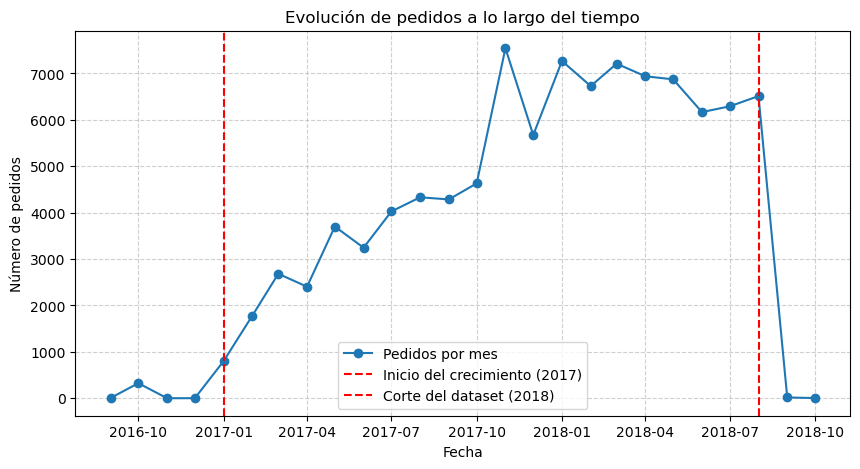

In [14]:
# Visualizamos el inicio del crecimiento de Olist y el fin de los datos relevantes de estudio 

plt.figure(figsize=(10,5))
plt.plot(orders_over_time.index, orders_over_time.values, marker='o', label='Pedidos por mes')

# Línea vertical para señalar el inicio del crecimiento
plt.axvline(pd.Timestamp('2017-01-01'), color='red', linestyle='--', label='Inicio del crecimiento (2017)')

# Línea vertical para señalar el corte de datos en el dataset
plt.axvline(pd.Timestamp('2018-08-01'), color='red', linestyle='--', label='Corte del dataset (2018)')

plt.title('Evolución de pedidos a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Olist empezó sus operaciones a finales de 2016, y el dataset refleja ese arranque. Los primeros meses (septiembre–diciembre) solo recogen unos pocos pedidos iniciales: pruebas internas, vendedores piloto o clientes tempranos. Aún no era una plataforma masiva.

Luego, a partir de enero de 2017, el volumen despega mes a mes. Ahí ya empieza la etapa de expansión comercial y de consolidación del negocio, que es cuando se vuelve un marketplace con miles de pedidos mensuales.

En resumen:

- 2016 → Periodo de arranque o recopilación inicial. Datos dispersos, casi simbólicos.

- Desde 2017 → Operación estable y crecimiento orgánico.

- 2018 → Estapa de madurez. A partir de septiembre no tenemos datos.

En el gráfico de esa evolución, el salto de 2016 a 2017 parece un “punto de inflexión” típico en una startup que empieza a escalar, y la bajada en septiembre de 2018 refleja que no tenemos datos para el análisis.

In [16]:
# Filtramos los pedidos dentro del periodo de análisis (ene 2017 - ago 2018) 
df_orders_filtered = df_orders[
    (df_orders['order_purchase_timestamp'] >= '2017-01-01') &
    (df_orders['order_purchase_timestamp'] < '2018-09-01')
]

# Agrupamos por mes y estado del pedido
orders_status_over_time_filtered = (
    df_orders_filtered
    .set_index('order_purchase_timestamp')
    .groupby([pd.Grouper(freq='MS'), 'order_status'])
    .size()
    .unstack(fill_value=0)
)

# Mostramos las últimas filas
orders_status_over_time_filtered.tail(25)

/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_83342/335266789.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([pd.Grouper(freq='MS'), 'order_status'])


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
order_purchase_timestamp,,,,,,,,
2017-01-01,0,3,0,750,12,9,16,10
2017-02-01,1,17,0,1653,11,32,21,45
2017-03-01,0,33,0,2546,3,23,45,32
2017-04-01,1,18,0,2303,14,10,49,9
2017-05-01,0,29,0,3546,16,23,55,31
2017-06-01,0,16,0,3135,11,12,47,24
2017-07-01,0,28,0,3872,7,11,56,52
2017-08-01,0,27,0,4193,20,18,41,32
2017-09-01,0,20,0,4150,17,22,38,38


Esta tabla será la base del análisis de pedidos.Aquí ya hemos filtrado los meses iniciales de 2016 y los finales de 2018 (septiembre y octubre), quedándonos solo con el periodo más representativo: de enero de 2017 a agosto de 2018.

De esta forma, trabajaremos con datos estables y comparables, eliminando los valores atípicos del arranque y del cierre del dataset.

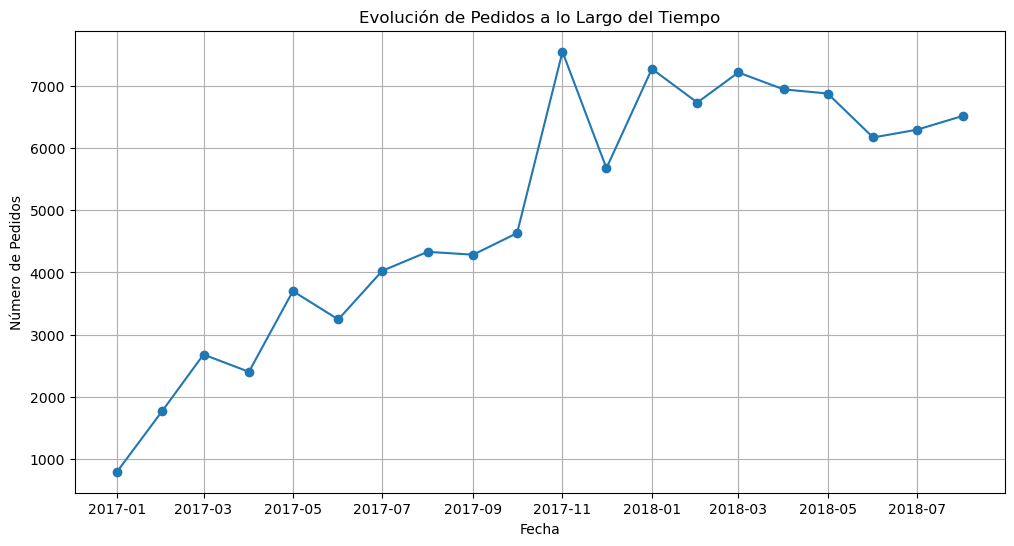

order_purchase_timestamp
2017-01-01     800
2017-02-01    1780
2017-03-01    2682
2017-04-01    2404
2017-05-01    3700
2017-06-01    3245
2017-07-01    4026
2017-08-01    4331
2017-09-01    4285
2017-10-01    4631
2017-11-01    7544
2017-12-01    5673
2018-01-01    7269
2018-02-01    6728
2018-03-01    7211
2018-04-01    6939
2018-05-01    6873
2018-06-01    6167
2018-07-01    6292
2018-08-01    6512
Freq: MS, dtype: int64


In [18]:
# Evolución de pedidos a lo largo del tiempo (pedidos ya filtrados)
orders_over_time_filtered = df_orders_filtered.set_index('order_purchase_timestamp').resample('MS').size()

import matplotlib.pyplot as plt         
plt.figure(figsize=(12, 6))
plt.plot(orders_over_time_filtered.index, orders_over_time_filtered.values, marker='o')
plt.title('Evolución de Pedidos a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos')
plt.grid()
plt.show()  

print(orders_over_time_filtered) 

In [19]:
# Convertimos la serie en DataFrame y renombramos las columnas para facilitar el análisis
df_orders_over_time_filtered = orders_over_time_filtered.reset_index()
df_orders_over_time_filtered.columns = ['order_purchase_timestamp', 'total_orders']

# Mostramos las últimas 25 filas para revisar los datos finales
df_orders_over_time_filtered.tail(25)

,order_purchase_timestamp,total_orders
0,2017-01-01,800
1,2017-02-01,1780
2,2017-03-01,2682
3,2017-04-01,2404
4,2017-05-01,3700
5,2017-06-01,3245
6,2017-07-01,4026
7,2017-08-01,4331
8,2017-09-01,4285
9,2017-10-01,4631


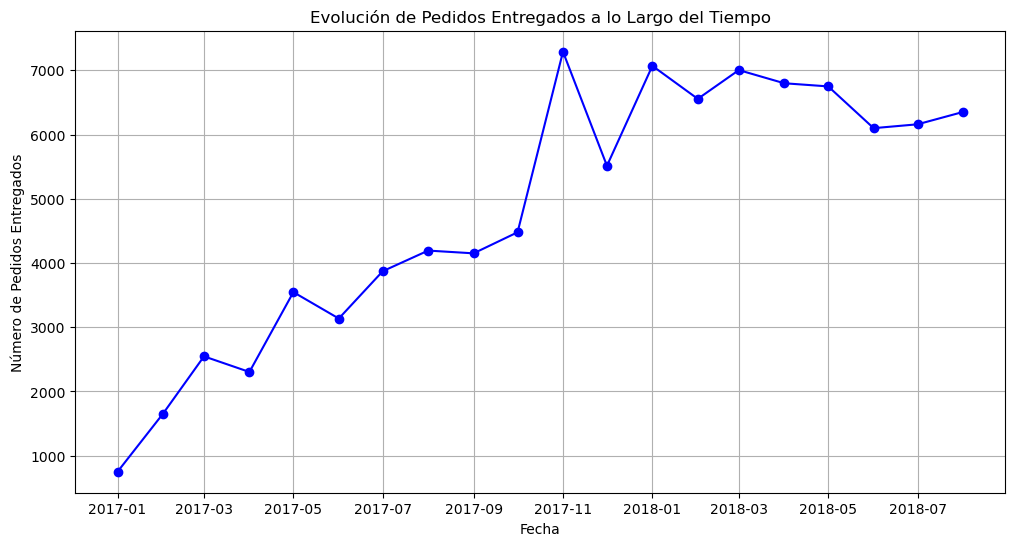

order_purchase_timestamp
2017-01-01     750
2017-02-01    1653
2017-03-01    2546
2017-04-01    2303
2017-05-01    3546
2017-06-01    3135
2017-07-01    3872
2017-08-01    4193
2017-09-01    4150
2017-10-01    4478
2017-11-01    7289
2017-12-01    5513
2018-01-01    7069
2018-02-01    6555
2018-03-01    7003
2018-04-01    6798
2018-05-01    6749
2018-06-01    6099
2018-07-01    6159
2018-08-01    6351
Freq: MS, dtype: int64

In [20]:
# Visualizamos la evolución mensual de los pedidos entregados dentro del periodo analizado
delivered_orders = df_orders_filtered[df_orders_filtered['order_status'] == 'delivered'].set_index('order_purchase_timestamp').resample('MS').size()

plt.figure(figsize=(12, 6))
plt.plot(delivered_orders.index, delivered_orders.values, marker='o', color='blue')
plt.title('Evolución de Pedidos Entregados a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos Entregados')
plt.grid()
plt.show()  

# Mostramos la serie con el número de pedidos entregados por mes
delivered_orders

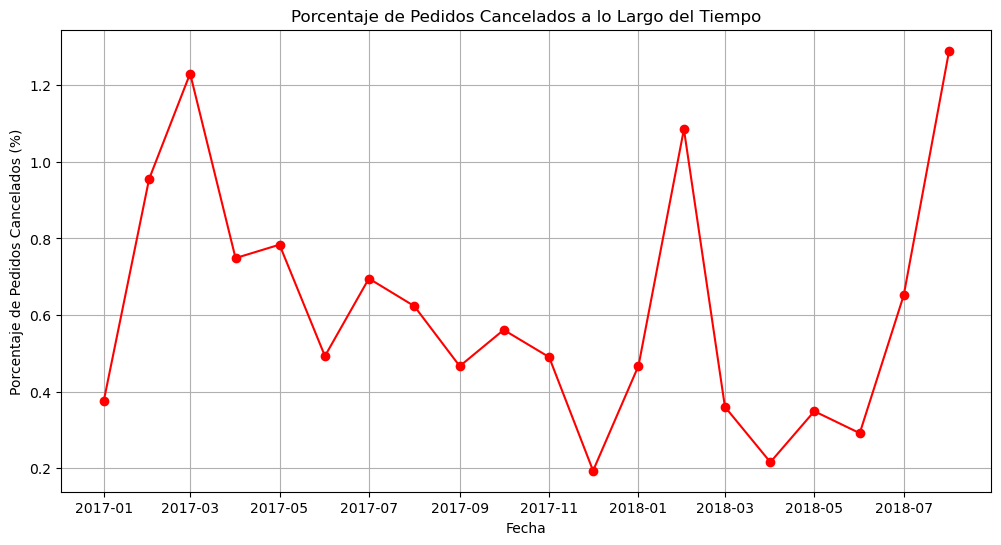

,cancelled_percentage
order_purchase_timestamp,
2017-01-01,0.375000
2017-02-01,0.955056
2017-03-01,1.230425
2017-04-01,0.748752
2017-05-01,0.783784
2017-06-01,0.493066
2017-07-01,0.695479
2017-08-01,0.623413
2017-09-01,0.466744


In [21]:
# Calculamos el porcentaje mensual de pedidos cancelados respecto al total y lo representamos gráficamente
cancelled_orders = df_orders_filtered[df_orders_filtered['order_status'] == 'canceled'].set_index('order_purchase_timestamp').resample('MS').size()
total_orders_filtered = df_orders_filtered.set_index('order_purchase_timestamp').resample('MS').size()
cancelled_percentage = (cancelled_orders / total_orders_filtered * 100).fillna(0)  
cancelled_percentage = cancelled_percentage.to_frame(name='cancelled_percentage')

plt.figure(figsize=(12, 6))
plt.plot(cancelled_percentage.index, cancelled_percentage.values, marker='o', color='red')
plt.title('Porcentaje de Pedidos Cancelados a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Porcentaje de Pedidos Cancelados (%)')
plt.grid()
plt.show()  

# Mostramos el porcentaje de cancelaciones por mes
cancelled_percentage

Hay tres meses que superan el 1 % de cancelaciones: marzo de 2017, febrero de 2018 y agosto de 2018.
En marzo de 2017, Olist aún estaba en fase de crecimiento y con menor volumen de pedidos, por lo que pequeñas incidencias tienen más peso en el porcentaje.
En febrero de 2018, ya en plena madurez del negocio, el repunte podría estar relacionado con los carnavales en Brasil, que afectan la logística y las entregas.
Y en agosto de 2018, el aumento se explica probablemente porque el dataset se corta en septiembre, dejando pedidos sin registrar como completados.

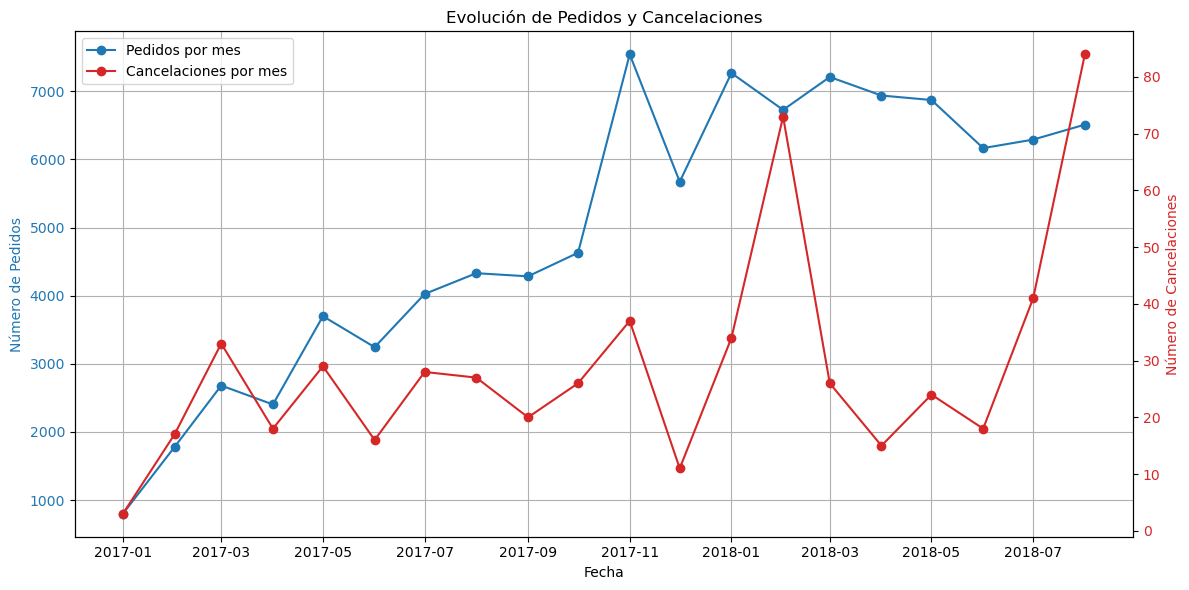

In [22]:
# Comparamos la evolución mensual de pedidos totales y cancelaciones en un mismo gráfico con doble eje
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: número total de pedidos
ax1.plot(orders_over_time_filtered.index, orders_over_time_filtered.values, marker='o', color='tab:blue', label='Pedidos por mes')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Número de Pedidos', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Eje derecho: número de cancelaciones
ax2 = ax1.twinx()
ax2.plot(cancelled_orders.index, cancelled_orders.values, marker='o', color='tab:red', label='Cancelaciones por mes')
ax2.set_ylabel('Número de Cancelaciones', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Título y leyenda combinada
plt.title('Evolución de Pedidos y Cancelaciones')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.grid()
fig.tight_layout()
plt.show()

En el gráfico se observa una relación clara entre el volumen de pedidos y las cancelaciones.
Durante febrero de 2018 se produce un pico notable de cancelaciones que coincide con una bajada temporal en los pedidos. Esto refuerza la hipótesis de que factores externos (como los carnavales o interrupciones logísticas) fectaron tanto a las entregas como al ritmo de compra.

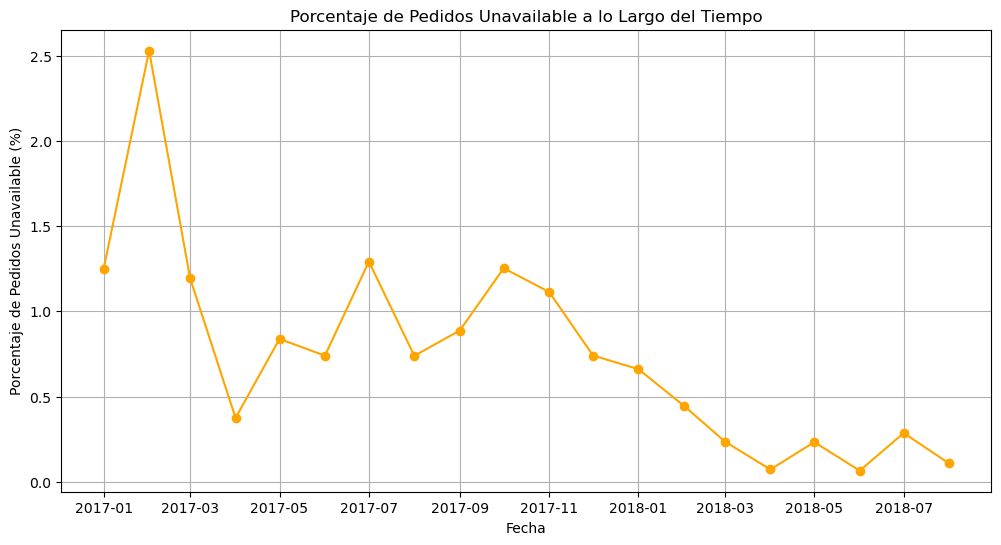

,unavailable_percentage
order_purchase_timestamp,
2017-01-01,1.250000
2017-02-01,2.528090
2017-03-01,1.193139
2017-04-01,0.374376
2017-05-01,0.837838
2017-06-01,0.739599
2017-07-01,1.291605
2017-08-01,0.738859
2017-09-01,0.886814


In [23]:
# Calculamos el porcentaje mensual de pedidos marcados como 'unavailable' respecto al total y lo visualizamos
unavailable_orders = df_orders_filtered[df_orders_filtered['order_status'] == 'unavailable'].set_index('order_purchase_timestamp').resample('MS').size()
total_orders_filtered = df_orders_filtered.set_index('order_purchase_timestamp').resample('MS').size()
unavailable_percentage = (unavailable_orders / total_orders_filtered * 100).fillna(0)
unavailable_percentage = unavailable_percentage.to_frame(name='unavailable_percentage')
         

plt.figure(figsize=(12, 6))     
plt.plot(unavailable_percentage.index, unavailable_percentage.values, marker='o', color='orange')
plt.title('Porcentaje de Pedidos Unavailable a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Porcentaje de Pedidos Unavailable (%)')
plt.grid()
plt.show()  

# Mostramos el porcentaje de pedidos 'unavailable' por mes
unavailable_percentage

El porcentaje de pedidos marcados como unavailable desciende de forma continua a lo largo del periodo analizado.
Durante los primeros meses de 2017 supera el 1 %, llegando incluso al 2,5 % en febrero, pero a partir de mediados de 2017 la tendencia es claramente descendente.

En 2018 los valores caen por debajo del 0,5 %, hasta acercarse prácticamente a cero en los últimos meses.
Esto indica una mejora progresiva en la gestión del inventario y en la coordinación entre Olist y los vendedores del marketplace.

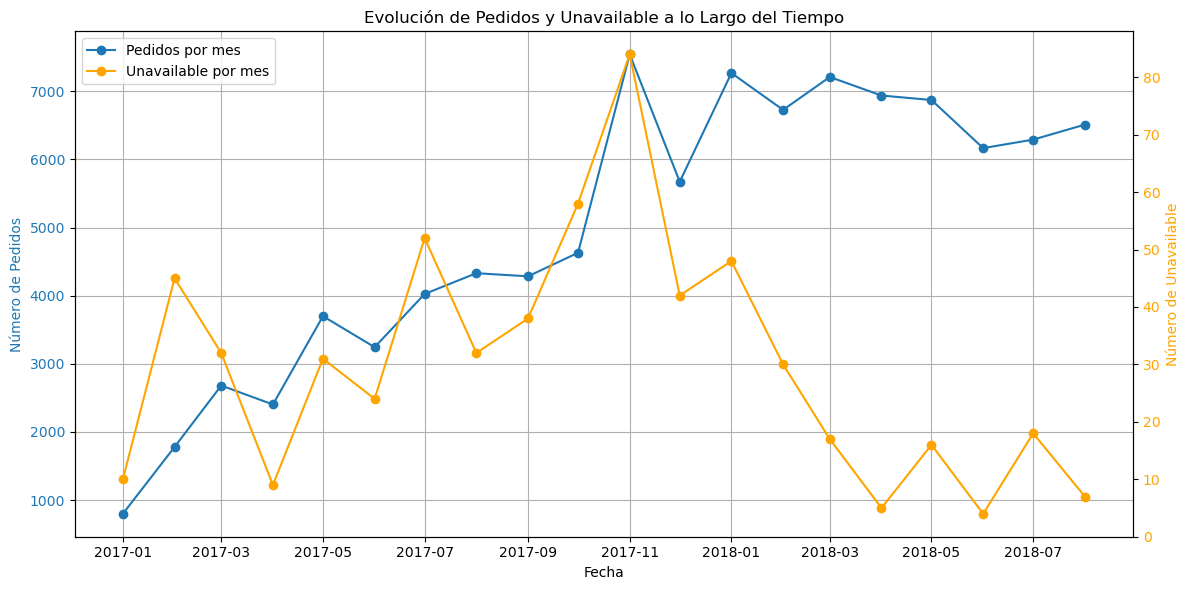

In [24]:
# Comparamos la evolución mensual de pedidos totales y pedidos 'unavailable' en un gráfico con doble eje
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: número total de pedidos
ax1.plot(orders_over_time_filtered.index, orders_over_time_filtered.values,
         marker='o', color='tab:blue', label='Pedidos por mes')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Número de Pedidos', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Eje derecho: número de pedidos 'unavailable'
ax2 = ax1.twinx()
ax2.plot(unavailable_orders.index, unavailable_orders.values,
         marker='o', color='orange', label='Unavailable por mes')
ax2.set_ylabel('Número de Unavailable', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Título y leyenda combinada
plt.title('Evolución de Pedidos y Unavailable a lo Largo del Tiempo')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.grid()
fig.tight_layout()
plt.show()

In [25]:
#Revisamos df orders filtrados
df_orders_filtered.head()

,id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,5,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


### Comprobar si hay relación entre los pedidos demorados y las cancelaciones

In [26]:
# Filtramos los pedidos que se entregaron más tarde de lo estimado (entregas demoradas)
df_pedidos_demorados = df_orders_filtered[df_orders_filtered['order_estimated_delivery_date'] < df_orders_filtered['order_delivered_customer_date']]

# Mostramos las primeras filas de los pedidos demorados
df_pedidos_demorados.head()

,id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
20,21,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28
25,26,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12
35,36,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,delivered,2018-02-17 15:59:46,2018-02-17 16:15:34,2018-02-20 23:03:56,2018-03-20 00:59:25,2018-03-20
41,42,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21
57,58,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02


In [27]:
# Agrupamos los pedidos demorados por mes para analizar su evolución temporal
df_demorados_por_mes = (
    df_pedidos_demorados
    .set_index('order_purchase_timestamp')
    .resample('MS')
    .size()
    .reset_index(name='pedidos_demorados')
)

df_demorados_por_mes.tail(20)

,order_purchase_timestamp,pedidos_demorados
0,2017-01-01,23
1,2017-02-01,53
2,2017-03-01,142
3,2017-04-01,181
4,2017-05-01,128
5,2017-06-01,121
6,2017-07-01,133
7,2017-08-01,139
8,2017-09-01,216
9,2017-10-01,237


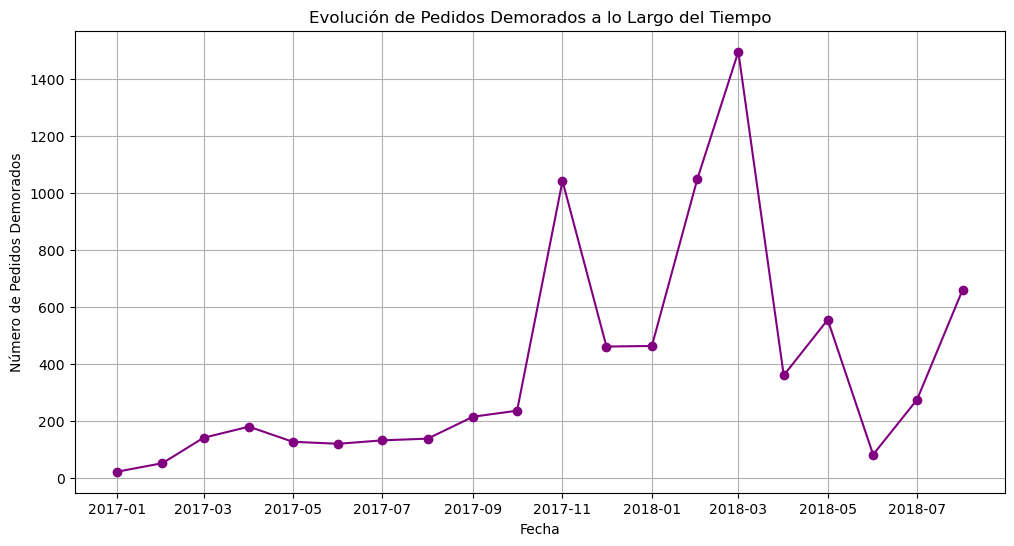

In [28]:
# Visualizamos la evolución mensual de los pedidos entregados con demora
df_pedidos_demorados_over_time = df_pedidos_demorados.set_index('order_purchase_timestamp').resample('MS').size()
plt.figure(figsize=(12, 6))
plt.plot(df_pedidos_demorados_over_time.index, df_pedidos_demorados_over_time.values, marker='o', color='purple')
plt.title('Evolución de Pedidos Demorados a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos Demorados')
plt.grid()
plt.show()  

In [29]:
# Calculamos los días de demora y filtramos los pedidos que se retrasaron más de 15 días
df_pedidos_demorados['dias_demorados'] = (df_pedidos_demorados['order_delivered_customer_date'] - df_pedidos_demorados['order_estimated_delivery_date']).dt.days
df_pedidos_demorados_mas_15 = df_pedidos_demorados[df_pedidos_demorados['dias_demorados'] > 15]

df_pedidos_demorados_mas_15.head()

/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_83342/4202382524.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pedidos_demorados['dias_demorados'] = (df_pedidos_demorados['order_delivered_customer_date'] - df_pedidos_demorados['order_estimated_delivery_date']).dt.days


,id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dias_demorados
97,98,6a0a8bfbbe700284feb0845d95e0867f,68451b39b1314302c08c65a29f1140fc,delivered,2017-11-22 11:32:22,2017-11-22 11:46:50,2017-11-27 13:39:35,2017-12-28 19:43:00,2017-12-11,17
110,111,9d531c565e28c3e0d756192f84d8731f,d4faa220408c20e53595d2950f361f3b,delivered,2017-11-28 21:00:44,2017-12-01 09:31:15,2017-12-14 20:37:43,2018-01-23 21:38:52,2017-12-22,32
115,116,8fc207e94fa91a7649c5a5dab690272a,c69f8b33e62ecb30ff78ae46d7fb9241,delivered,2017-11-26 17:49:46,2017-11-26 17:58:34,2017-11-28 23:17:09,2018-01-20 13:42:22,2017-12-19,32
252,253,f31535f21d145b2345e2bf7f09d62322,ed532487db04478dfba09d112649fc13,delivered,2018-02-01 07:47:34,2018-02-01 08:10:31,2018-02-02 00:24:34,2018-04-23 15:49:34,2018-03-05,49
445,446,690199d6a2c51ff57c6b392d7680cbfd,19bacb562bd43bd4eaf05b6c0a59dad0,delivered,2018-03-16 11:31:18,2018-03-16 11:49:14,2018-03-19 19:56:23,2018-05-14 12:28:56,2018-04-11,33


In [30]:
# Agrupamos los pedidos con más de 15 días de demora por mes para analizar su evolución temporal
df_demorados_15_por_mes = (
    df_pedidos_demorados_mas_15
    .set_index('order_purchase_timestamp')
    .resample('MS')
    .size()
    .reset_index(name='pedidos_demorados_mas_15')
)

df_demorados_15_por_mes.tail(20)

,order_purchase_timestamp,pedidos_demorados_mas_15
0,2017-01-01,13
1,2017-02-01,16
2,2017-03-01,34
3,2017-04-01,22
4,2017-05-01,19
5,2017-06-01,20
6,2017-07-01,27
7,2017-08-01,15
8,2017-09-01,31
9,2017-10-01,32


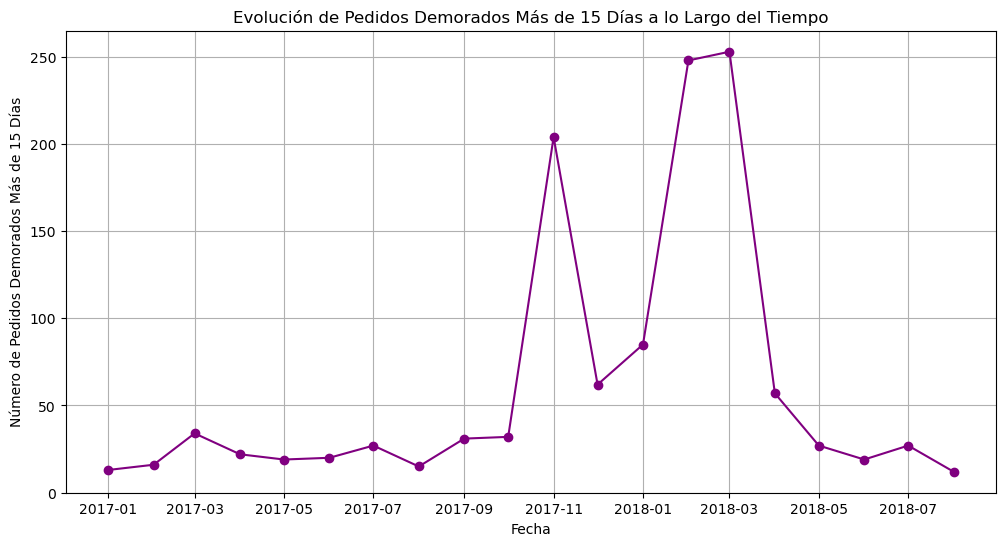

In [32]:
# Visualizamos la evolución mensual de los pedidos con más de 15 días de demora 
df_pedidos_demorados_mas_15_over_time = df_pedidos_demorados_mas_15.set_index('order_purchase_timestamp').resample('MS').size()
plt.figure(figsize=(12, 6))
plt.plot(df_pedidos_demorados_mas_15_over_time.index, df_pedidos_demorados_mas_15_over_time.values, marker='o', color='purple')
plt.title('Evolución de Pedidos Demorados Más de 15 Días a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos Demorados Más de 15 Días')
plt.grid()
plt.show()  

In [33]:
# Calculamos los días de demora y filtramos los pedidos que se retrasaron más de 30 días
df_pedidos_demorados['dias_demorados'] = (df_pedidos_demorados['order_delivered_customer_date'] - df_pedidos_demorados['order_estimated_delivery_date']).dt.days
df_pedidos_demorados_mas_30 = df_pedidos_demorados[df_pedidos_demorados['dias_demorados'] > 30]

df_pedidos_demorados_mas_30.head()

/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_83342/3588691301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pedidos_demorados['dias_demorados'] = (df_pedidos_demorados['order_delivered_customer_date'] - df_pedidos_demorados['order_estimated_delivery_date']).dt.days


,id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dias_demorados
110,111,9d531c565e28c3e0d756192f84d8731f,d4faa220408c20e53595d2950f361f3b,delivered,2017-11-28 21:00:44,2017-12-01 09:31:15,2017-12-14 20:37:43,2018-01-23 21:38:52,2017-12-22,32
115,116,8fc207e94fa91a7649c5a5dab690272a,c69f8b33e62ecb30ff78ae46d7fb9241,delivered,2017-11-26 17:49:46,2017-11-26 17:58:34,2017-11-28 23:17:09,2018-01-20 13:42:22,2017-12-19,32
252,253,f31535f21d145b2345e2bf7f09d62322,ed532487db04478dfba09d112649fc13,delivered,2018-02-01 07:47:34,2018-02-01 08:10:31,2018-02-02 00:24:34,2018-04-23 15:49:34,2018-03-05,49
445,446,690199d6a2c51ff57c6b392d7680cbfd,19bacb562bd43bd4eaf05b6c0a59dad0,delivered,2018-03-16 11:31:18,2018-03-16 11:49:14,2018-03-19 19:56:23,2018-05-14 12:28:56,2018-04-11,33
658,659,cafc9b2f7d35ec42bdb74347cc6e8a70,c9573cc1e246dadca50b2a74f795def3,delivered,2018-01-19 00:48:30,2018-01-19 01:21:52,2018-01-19 22:41:38,2018-04-04 17:12:36,2018-02-16,47


In [34]:
# Agrupamos los pedidos con más de 30 días de demora por mes para analizar su evolución temporal

df_demorados_30_por_mes = (
    df_pedidos_demorados_mas_30
    .set_index('order_purchase_timestamp')
    .resample('MS')
    .size()
    .reset_index(name='pedidos_demorados_mas_30')
)

df_demorados_30_por_mes.tail(20)

,order_purchase_timestamp,pedidos_demorados_mas_30
0,2017-01-01,3
1,2017-02-01,5
2,2017-03-01,22
3,2017-04-01,8
4,2017-05-01,8
5,2017-06-01,10
6,2017-07-01,7
7,2017-08-01,4
8,2017-09-01,7
9,2017-10-01,7


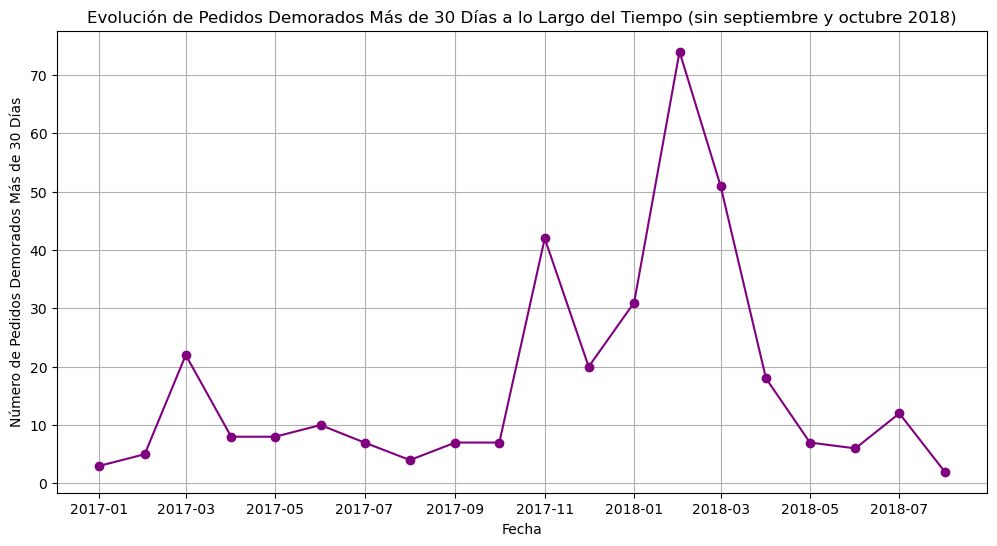

In [35]:
# Visualizamos la evolución mensual de los pedidos con más de 30 días de demora 
df_pedidos_demorados_mas_30_over_time = df_pedidos_demorados_mas_30.set_index('order_purchase_timestamp').resample('MS').size()
plt.figure(figsize=(12, 6))
plt.plot(df_pedidos_demorados_mas_30_over_time.index, df_pedidos_demorados_mas_30_over_time.values, marker='o', color='purple')
plt.title('Evolución de Pedidos Demorados Más de 30 Días a lo Largo del Tiempo (sin septiembre y octubre 2018)')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos Demorados Más de 30 Días')
plt.grid()
plt.show()

In [36]:
# Combinamos en un solo DataFrame la cantidad de pedidos demorados, los demorados más de 15 días y más de 30 días por mes
df_comparativa = df_demorados_por_mes.merge(
    df_demorados_15_por_mes, on='order_purchase_timestamp', how='left'
).merge(
    df_demorados_30_por_mes, on='order_purchase_timestamp', how='left'
).fillna(0)

df_comparativa.tail(20)

,order_purchase_timestamp,pedidos_demorados,pedidos_demorados_mas_15,pedidos_demorados_mas_30
0,2017-01-01,23,13,3
1,2017-02-01,53,16,5
2,2017-03-01,142,34,22
3,2017-04-01,181,22,8
4,2017-05-01,128,19,8
5,2017-06-01,121,20,10
6,2017-07-01,133,27,7
7,2017-08-01,139,15,4
8,2017-09-01,216,31,7
9,2017-10-01,237,32,7


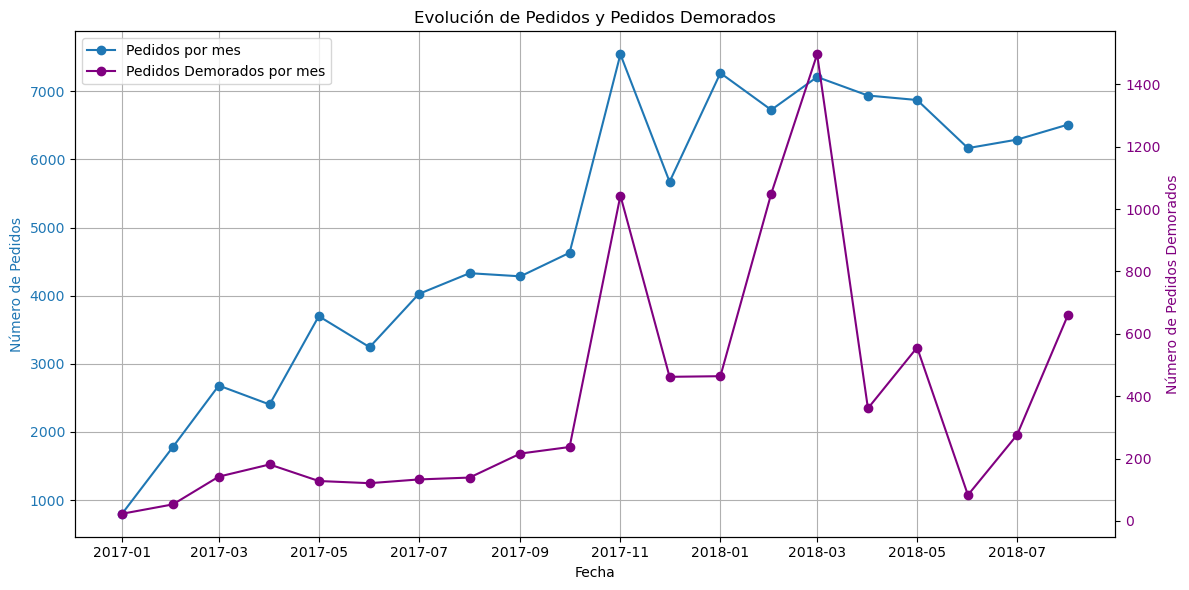

In [37]:
# Comparamos la evolución mensual de los pedidos totales y los pedidos demorados en un gráfico con doble eje
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: número total de pedidos
ax1.plot(
    orders_over_time_filtered.index,
    orders_over_time_filtered.values,
    marker='o', color='tab:blue', label='Pedidos por mes'
)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Número de Pedidos', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Eje derecho: número de pedidos demorados
ax2 = ax1.twinx()
ax2.plot(
    df_pedidos_demorados_over_time.index,
    df_pedidos_demorados_over_time.values,
    marker='o', color='purple', label='Pedidos Demorados por mes'
)
ax2.set_ylabel('Número de Pedidos Demorados', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Título y leyenda combinada
plt.title('Evolución de Pedidos y Pedidos Demorados')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.grid()
fig.tight_layout()
plt.show()

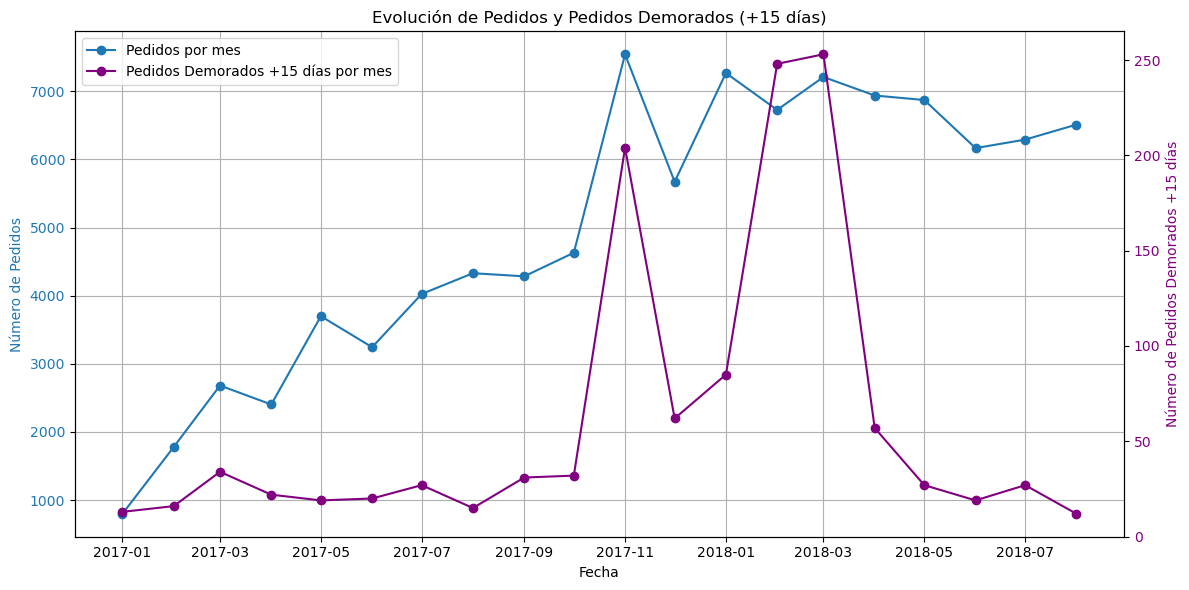

In [38]:
# Comparamos la evolución mensual de los pedidos totales y los pedidos demorados más de 15 días usando doble eje
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: número total de pedidos
ax1.plot(
    orders_over_time_filtered.index,
    orders_over_time_filtered.values,
    marker='o', color='tab:blue', label='Pedidos por mes'
)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Número de Pedidos', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Eje derecho: número de pedidos demorados más de 15 días
ax2 = ax1.twinx()
ax2.plot(
    df_pedidos_demorados_mas_15_over_time.index,
    df_pedidos_demorados_mas_15_over_time.values,
    marker='o', color='purple', label='Pedidos Demorados +15 días por mes'
)
ax2.set_ylabel('Número de Pedidos Demorados +15 días', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Título y leyenda combinada
plt.title('Evolución de Pedidos y Pedidos Demorados (+15 días)')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.grid()
fig.tight_layout()
plt.show()

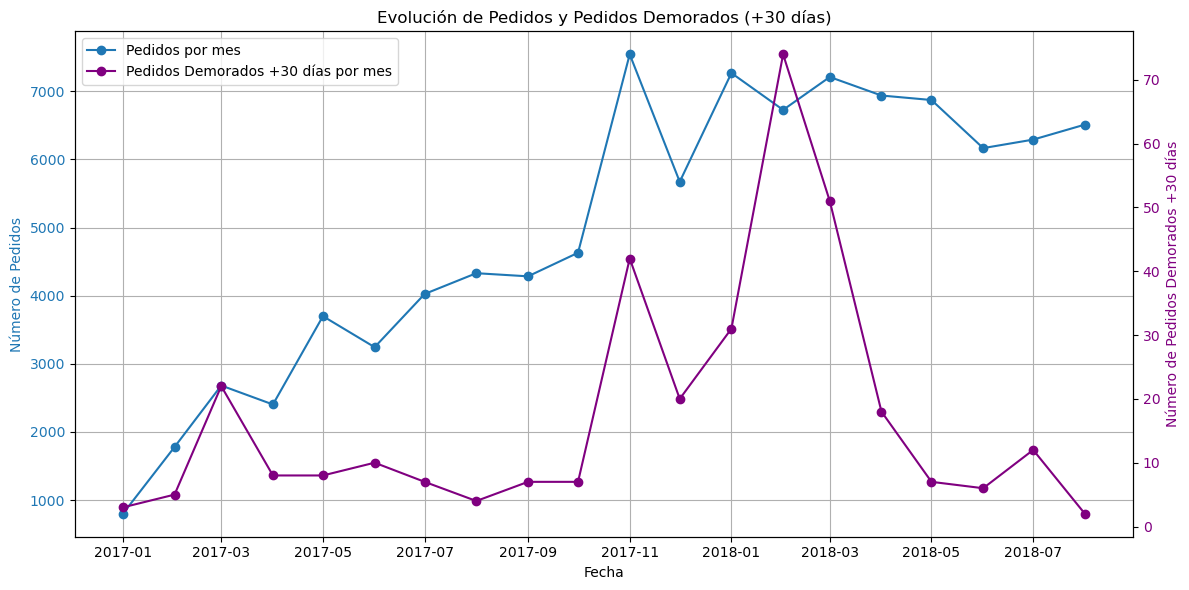

In [39]:
# Comparamos la evolución mensual de los pedidos totales y los pedidos demorados más de 30 días en un gráfico con doble eje
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: número total de pedidos
ax1.plot(
    orders_over_time_filtered.index,
    orders_over_time_filtered.values,
    marker='o', color='tab:blue', label='Pedidos por mes'
)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Número de Pedidos', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Eje derecho: número de pedidos demorados más de 30 días
ax2 = ax1.twinx()
ax2.plot(
    df_pedidos_demorados_mas_30_over_time.index,
    df_pedidos_demorados_mas_30_over_time.values,
    marker='o', color='purple', label='Pedidos Demorados +30 días por mes'
)
ax2.set_ylabel('Número de Pedidos Demorados +30 días', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Título y leyenda combinada
plt.title('Evolución de Pedidos y Pedidos Demorados (+30 días)')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.grid()
fig.tight_layout()
plt.show()

En la evolución de pedidos demorados se observan tres picos claros: noviembre de 2017, febrero de 2018 y marzo de 2018.
El primero coincide con la campaña del Black Friday, cuando el volumen de pedidos aumenta bruscamente y las demoras logísticas son habituales.
Los dos siguientes (febrero y marzo de 2018) podrían estar relacionados con el periodo de carnavales en Brasil, que suele afectar la actividad comercial y los plazos de entrega.

En los pedidos demorados más de 15 días la tendencia es muy similar, reforzando la idea de que esos meses concentraron tensiones logísticas.
Sin embargo, al mirar los retrasos superiores a 30 días, febrero de 2018 destaca con diferencia sobre el resto, lo que coincide también con el aumento de cancelaciones detectado en ese mismo mes.

Todo apunta a que los problemas logísticos de febrero impactaron tanto en los tiempos de entrega como en la tasa de cancelaciones.

### # Comparamos la evolución mensual de los pedidos demorados más de 30 días y las cancelaciones para acabar de afirmar la relación

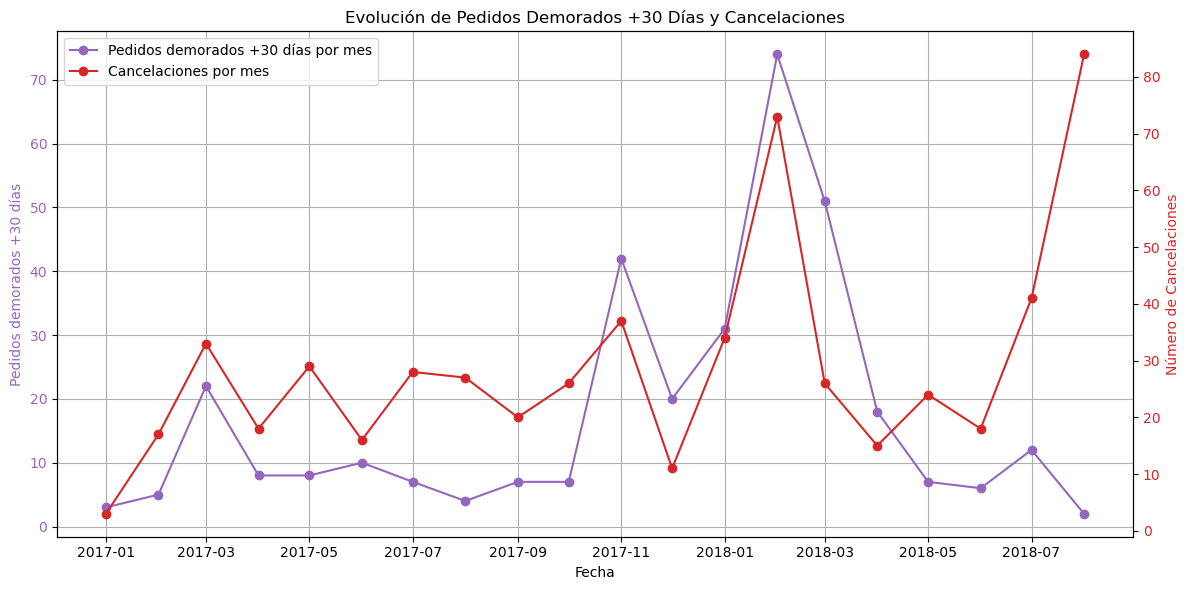

In [40]:
# Comparamos la evolución mensual de los pedidos demorados más de 30 días y las cancelaciones para detectar posibles relaciones
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: pedidos demorados más de 30 días
ax1.plot(
    df_pedidos_demorados_mas_30_over_time.index,
    df_pedidos_demorados_mas_30_over_time.values,
    marker='o', color='tab:purple', label='Pedidos demorados +30 días por mes'
)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Pedidos demorados +30 días', color='tab:purple')
ax1.tick_params(axis='y', labelcolor='tab:purple')

# Eje derecho: número de cancelaciones
ax2 = ax1.twinx()
ax2.plot(
    cancelled_orders.index,
    cancelled_orders.values,
    marker='o', color='tab:red', label='Cancelaciones por mes'
)
ax2.set_ylabel('Número de Cancelaciones', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Título y leyenda combinada
plt.title('Evolución de Pedidos Demorados +30 Días y Cancelaciones')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.grid()
fig.tight_layout()
plt.show()

En este gráfico se aprecia una coincidencia evidente entre los picos de pedidos demorados más de 30 días y las cancelaciones.
El punto más destacado es febrero de 2018, donde ambas curvas se disparan de forma simultánea, confirmando la relación entre los retrasos prolongados y el aumento de cancelaciones.

Todo apunta a que este comportamiento está relacionado con los carnavales de Brasil, celebrados justo en ese mes, que probablemente afectaron la logística y los tiempos de entrega.
Aunque hay algunos repuntes menores en otros periodos (Marzo y Noviembre), ninguno alcanza la magnitud del de febrero, lo que refuerza la idea de que fue una disrupción puntual y no un patrón estructural.

### 9. TABLA: product_category_name_translation

In [41]:
# Exploramos product_category_name_translation
df_product_cat = explore_table("product_category_name_translation")

Tabla: product_category_name_translation
Dimensiones: (71, 3)

Tipos de datos:


id                                int64
product_category_name            object
product_category_name_english    object
dtype: object


Valores nulos por columna:


id                               0
product_category_name            0
product_category_name_english    0
dtype: int64


Duplicados (filas completas): 0

Primeras 5 filas:


,id,product_category_name,product_category_name_english
0,1,beleza_saude,health_beauty
1,2,informatica_acessorios,computers_accessories
2,3,automotivo,auto
3,4,cama_mesa_banho,bed_bath_table
4,5,moveis_decoracao,furniture_decor


### 7. TABLA: olist_products_dataset

In [42]:
# Exploramos products
df_products = explore_table("olist_products_dataset")

Tabla: olist_products_dataset
Dimensiones: (32951, 10)

Tipos de datos:


id                              int64
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


Valores nulos por columna:


id                              0
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


Duplicados (filas completas): 0

Primeras 5 filas:


,id,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,2,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,3,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,4,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,5,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### Unimos las categorias traducidas en inglés al df_products

In [43]:
# Unimos la tabla de productos con la de traducciones de categorías para añadir los nombres traducidos
df_products_merged = df_products.merge(
    df_product_cat,
    on='product_category_name',
    how='left'
)

#Comprobamos
df_products_merged.head()

,id_x,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,id_y,product_category_name_english
0,1,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,7.0,perfumery
1,2,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,47.0,art
2,3,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,6.0,sports_leisure
3,4,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,12.0,baby
4,5,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,8.0,housewares


In [44]:
# Filtrar solo los pedidos cancelados
df_orders_canceled = df_orders[df_orders['order_status'] == 'canceled']

# Añadimos la información de productos y sus traducciones
df_canceled_items = df_orders_canceled.merge(
    df_order_items,
    on='order_id',
    how='inner'
)

# Añadimos la información de productos y sus traducciones
df_canceled_products = df_canceled_items.merge(
    df_products_merged,
    on='product_id',
    how='left'
)

# Agrupamos por categoría traducida y contamos el número de cancelaciones por categoría
df_canceled_by_category = (
    df_canceled_products
    .groupby('product_category_name_english')
    .size()
    .reset_index(name='num_canceled_orders')
    .sort_values(by='num_canceled_orders', ascending=False)
)

df_canceled_by_category.head(10)

,product_category_name_english,num_canceled_orders
41,sports_leisure,51
32,housewares,49
8,computers_accessories,46
28,health_beauty,36
25,furniture_decor,36
44,toys,34
3,auto,30
45,watches_gifts,21
4,baby,20
27,garden_tools,19


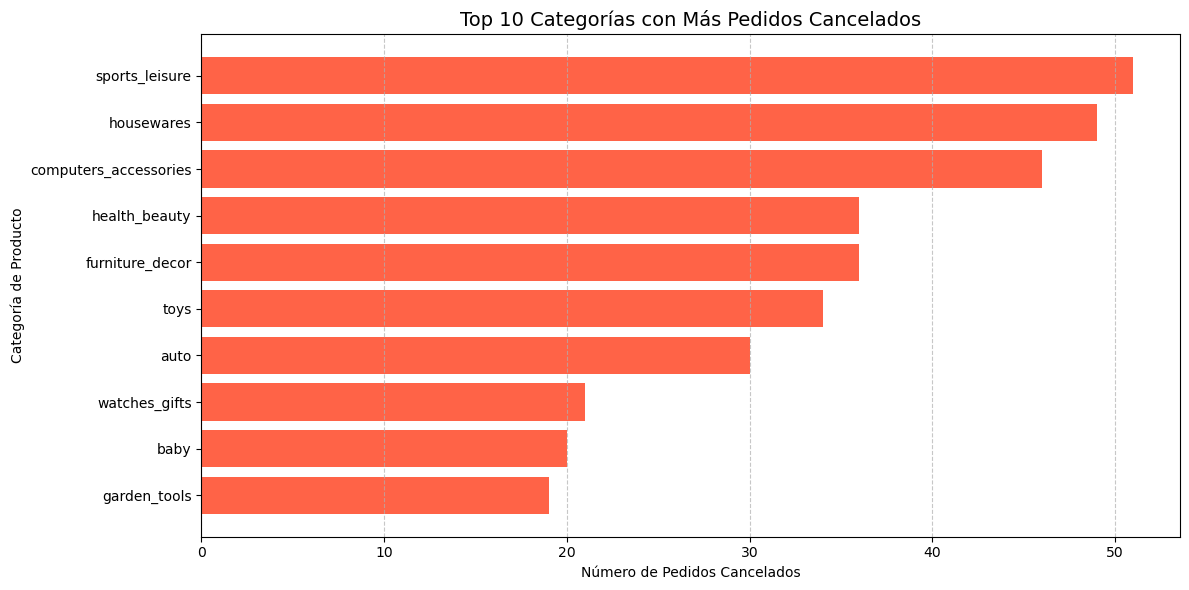

In [45]:
# Visualizamos las 10 categorías de productos con mayor número de pedidos cancelados
top10_canceladas = df_canceled_by_category.head(10)

plt.figure(figsize=(12,6))
plt.barh(top10_canceladas['product_category_name_english'], top10_canceladas['num_canceled_orders'], color='tomato')
plt.gca().invert_yaxis()  # Para que la categoría con más cancelaciones aparezca arriba
plt.title('Top 10 Categorías con Más Pedidos Cancelados', fontsize=14)
plt.xlabel('Número de Pedidos Cancelados')
plt.ylabel('Categoría de Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
# Filtramos los pedidos marcados como 'unavailable'
df_orders_unavailable = df_orders[df_orders['order_status'] == 'unavailable']

# Unimos los pedidos 'unavailable' con la tabla de items para obtener los productos implicados
df_unavailable_items = df_orders_unavailable.merge(
    df_order_items,
    on='order_id',
    how='inner'
)

# Añadimos la información de productos y sus traducciones
df_unavailable_products = df_unavailable_items.merge(
    df_products_merged,
    on='product_id',
    how='left'
)

# Agrupamos por categoría traducida y contamos cuántos pedidos 'unavailable' tiene cada una
df_unavailable_by_category = (
    df_unavailable_products
    .groupby('product_category_name_english')
    .size()
    .reset_index(name='num_unavailable_orders')
    .sort_values(by='num_unavailable_orders', ascending=False)
)

df_unavailable_by_category.head(10)

,product_category_name_english,num_unavailable_orders
1,baby,2
4,perfumery,2
0,auto,1
2,cool_stuff,1
3,electronics,1


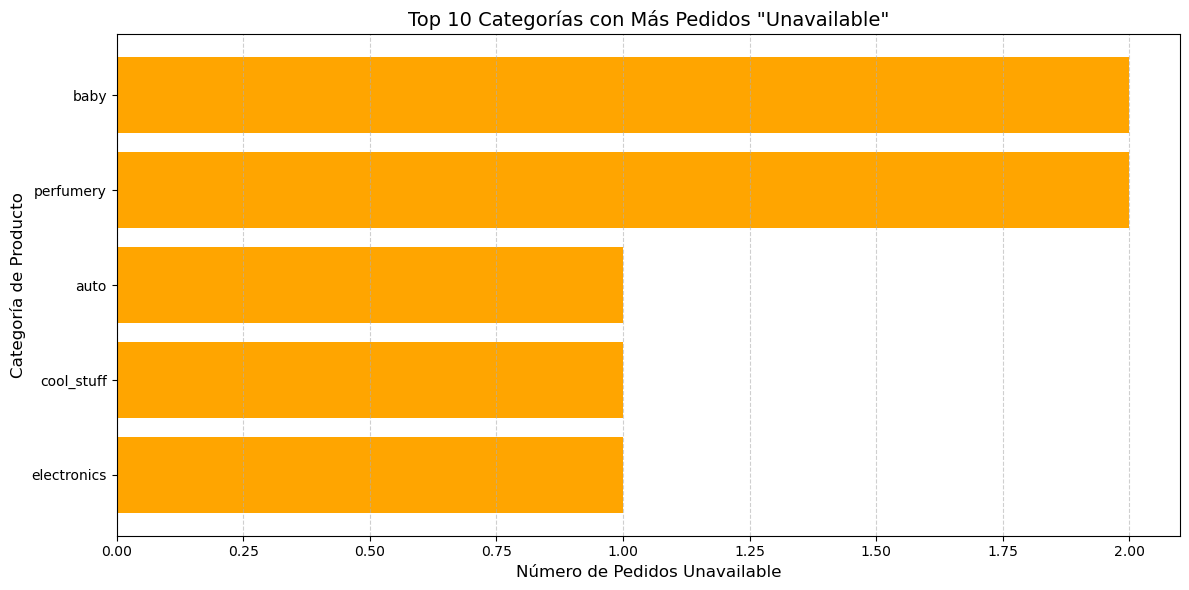

In [48]:
# Visualizamos las 10 categorías con mayor número de pedidos marcados como 'unavailable'
plt.figure(figsize=(12, 6))
plt.barh(
    df_unavailable_by_category.head(10)['product_category_name_english'],
    df_unavailable_by_category.head(10)['num_unavailable_orders'],
    color='orange'
)
plt.gca().invert_yaxis() 
plt.title('Top 10 Categorías con Más Pedidos "Unavailable"', fontsize=14)
plt.xlabel('Número de Pedidos Unavailable', fontsize=12)
plt.ylabel('Categoría de Producto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [49]:
# Filtramos los pedidos que se entregaron más tarde de lo estimado (pedidos demorados)
df_orders_delayed = df_orders[
    (df_orders['order_delivered_customer_date'].notnull()) &
    (df_orders['order_estimated_delivery_date'] < df_orders['order_delivered_customer_date'])
]

# Unimos los pedidos demorados con la tabla de items para obtener el detalle de productos
df_delayed_items = df_orders_delayed.merge(
    df_order_items,
    on='order_id',
    how='inner'
)

# Añadimos la información de productos y sus traducciones
df_delayed_products = df_delayed_items.merge(
    df_products_merged,
    on='product_id',
    how='left'
)

# Agrupamos por categoría traducida y contamos cuántos pedidos demorados tiene cada una
df_delayed_by_category = (
    df_delayed_products
    .groupby('product_category_name_english')
    .size()
    .reset_index(name='num_delayed_orders')
    .sort_values(by='num_delayed_orders', ascending=False)
)

df_delayed_by_category.head(10)

,product_category_name_english,num_delayed_orders
7,bed_bath_table,920
41,health_beauty,858
37,furniture_decor,688
61,sports_leisure,625
14,computers_accessories,594
66,watches_gifts,485
47,housewares,441
64,telephony,369
5,auto,343
40,garden_tools,340


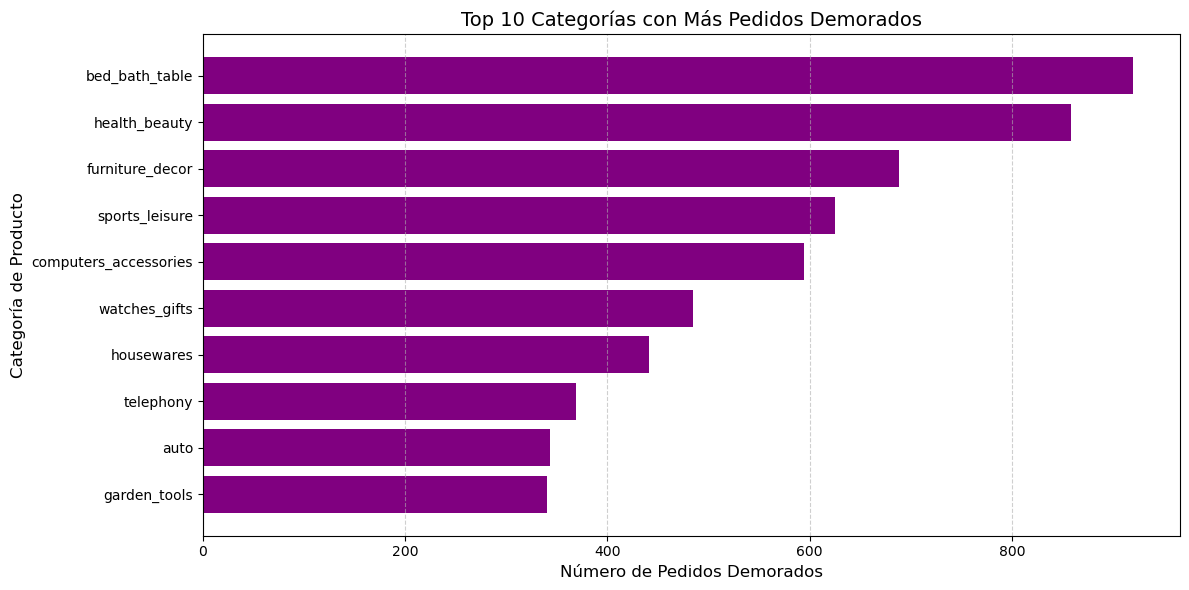

In [51]:
# Visualizamos las 10 categorías de productos con mayor número de pedidos demorados
plt.figure(figsize=(12, 6))
plt.barh(
    df_delayed_by_category.head(10)['product_category_name_english'],
    df_delayed_by_category.head(10)['num_delayed_orders'],
    color='purple'
)
plt.gca().invert_yaxis()  # Muestra primero la categoría con más demoras
plt.title('Top 10 Categorías con Más Pedidos Demorados', fontsize=14)
plt.xlabel('Número de Pedidos Demorados', fontsize=12)
plt.ylabel('Categoría de Producto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [52]:
# Calculamos los días de retraso para los pedidos entregados
df_orders_delayed['delay_days'] = (
    df_orders_delayed['order_delivered_customer_date'] - df_orders_delayed['order_estimated_delivery_date']
).dt.days

# Filtramos los pedidos que se retrasaron más de 30 días
df_orders_delayed_30 = df_orders_delayed[df_orders_delayed['delay_days'] > 30]

# Unimos con la tabla de items para obtener el detalle de productos
df_delayed_items_30 = df_orders_delayed_30.merge(
    df_order_items,
    on='order_id',
    how='inner'
)

# Añadimos información de productos y sus traducciones
df_delayed_products_30 = df_delayed_items_30.merge(
    df_products_merged,
    on='product_id',
    how='left'
)

# Agrupamos por categoría traducida y contamos los pedidos demorados más de 30 días
df_delayed_by_category_30 = (
    df_delayed_products_30
    .groupby('product_category_name_english')
    .size()
    .reset_index(name='num_delayed_orders')
    .sort_values(by='num_delayed_orders', ascending=False)
)

# Mostramos las 10 categorías con más pedidos demorados (+30 días)
df_delayed_by_category_30.head(10)

/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_83342/31180913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_orders_delayed['delay_days'] = (


,product_category_name_english,num_delayed_orders
3,bed_bath_table,42
16,furniture_decor,41
20,health_beauty,37
33,sports_leisure,28
6,computers_accessories,23
1,auto,21
2,baby,16
36,toys,15
10,cool_stuff,14
25,housewares,14


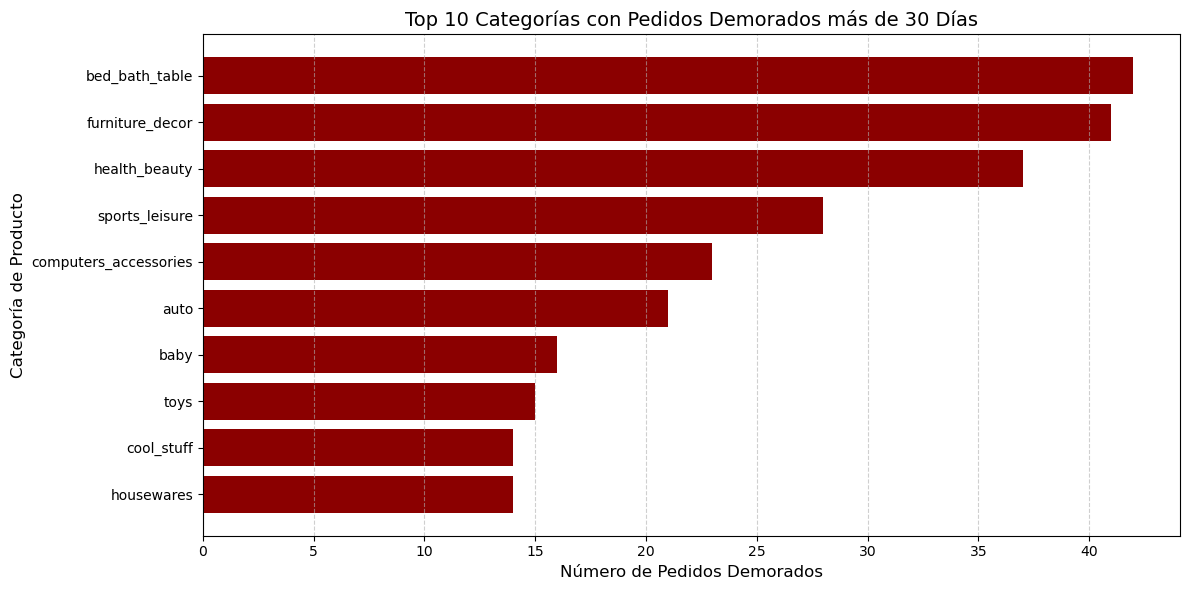

In [53]:
# Visualizamos las 10 categorías con mayor número de pedidos demorados más de 30 días
plt.figure(figsize=(12, 6))
plt.barh(
    df_delayed_by_category_30.head(10)['product_category_name_english'],
    df_delayed_by_category_30.head(10)['num_delayed_orders'],
    color='darkred'
)
plt.gca().invert_yaxis()
plt.title('Top 10 Categorías con Pedidos Demorados más de 30 Días', fontsize=14)
plt.xlabel('Número de Pedidos Demorados', fontsize=12)
plt.ylabel('Categoría de Producto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Vamos a crear df con el total de pedidos, pedidos cancelados, demorados y unavainable por si vemos alguna relacion más

In [62]:
# Unimos las tablas para obtener la información completa de pedidos, productos y estados
df_orders_items_products = (
    df_order_items
    .merge(df_products_merged, on='product_id', how='left')
    .merge(df_orders[['order_id', 'order_status', 'order_delivered_customer_date', 'order_estimated_delivery_date']],
           on='order_id', how='left')
)

In [63]:
# Calculamos el total de pedidos por categoría
df_total = (
    df_orders_items_products
    .groupby('product_category_name_english')
    .size()
    .reset_index(name='total_orders')
)

In [64]:
# Calculamos los pedidos cancelados por categoría
df_canceled = (
    df_orders_items_products[df_orders_items_products['order_status'] == 'canceled']
    .groupby('product_category_name_english')
    .size()
    .reset_index(name='canceled_orders')
)

In [65]:
# Calculamos los pedidos 'unavailable' por categoría
df_unavailable = (
    df_orders_items_products[df_orders_items_products['order_status'] == 'unavailable']
    .groupby('product_category_name_english')
    .size()
    .reset_index(name='unavailable_orders')
)

In [66]:
# Calculamos los pedidos demorados por categoría
df_delayed = (
    df_orders_items_products[
        (df_orders_items_products['order_delivered_customer_date'].notnull()) &
        (df_orders_items_products['order_estimated_delivery_date'] < df_orders_items_products['order_delivered_customer_date'])
    ]
    .groupby('product_category_name_english')
    .size()
    .reset_index(name='delayed_orders')
)

In [67]:
# Unimos todos los resultados en un solo DataFrame resumen
df_summary = (
    df_total
    .merge(df_canceled, on='product_category_name_english', how='left')
    .merge(df_unavailable, on='product_category_name_english', how='left')
    .merge(df_delayed, on='product_category_name_english', how='left')
)

In [68]:
# Rellenamos valores nulos y calculamos los porcentajes por categoría
df_summary = df_summary.fillna(0)
df_summary['%_canceled'] = (df_summary['canceled_orders'] / df_summary['total_orders'] * 100).round(2)
df_summary['%_unavailable'] = (df_summary['unavailable_orders'] / df_summary['total_orders'] * 100).round(2)
df_summary['%_delayed'] = (df_summary['delayed_orders'] / df_summary['total_orders'] * 100).round(2)

In [69]:
# Ordenamos las categorías por el total de pedidos
df_summary = df_summary.sort_values(by='total_orders', ascending=False)

# Mostramos las 10 primeras categorías del resumen
df_summary.head(10)

,product_category_name_english,total_orders,canceled_orders,unavailable_orders,delayed_orders,%_canceled,%_unavailable,%_delayed
7,bed_bath_table,11115,18.0,0.0,920.0,0.16,0.00,8.28
43,health_beauty,9670,36.0,0.0,858.0,0.37,0.00,8.87
65,sports_leisure,8641,51.0,0.0,625.0,0.59,0.00,7.23
39,furniture_decor,8334,36.0,0.0,688.0,0.43,0.00,8.26
15,computers_accessories,7827,46.0,0.0,594.0,0.59,0.00,7.59
49,housewares,6964,49.0,0.0,441.0,0.70,0.00,6.33
70,watches_gifts,5991,21.0,0.0,485.0,0.35,0.00,8.10
68,telephony,4545,18.0,0.0,369.0,0.40,0.00,8.12
42,garden_tools,4347,19.0,0.0,340.0,0.44,0.00,7.82
5,auto,4235,30.0,1.0,343.0,0.71,0.02,8.10


En este resumen de las 10 categorías con mayor volumen de pedidos se observa que las incidencias no son especialmente altas en porcentaje, pero sí consistentes entre categorías.
Las cancelaciones se mantienen por debajo del 1 % en todos los casos, mientras que los retrasos (pedidos demorados) oscilan entre el 6 % y el 9 %.

Las categorías health_beauty, furniture_decor, bed_bath_table y telephony destacan por tener los mayores porcentajes de demoras, rondando o superando el 8 %.
Esto sugiere que, aunque la operación general es estable, los productos de mayor tamaño o más frágiles tienden a presentar más complicaciones logísticas.

El dato de unavailable es casi nulo, pero probablemente no sea del todo representativo: puede que en muchos casos en que un producto no estaba disponible no se haya registrado correctamente su categoría o el estado final del pedido.

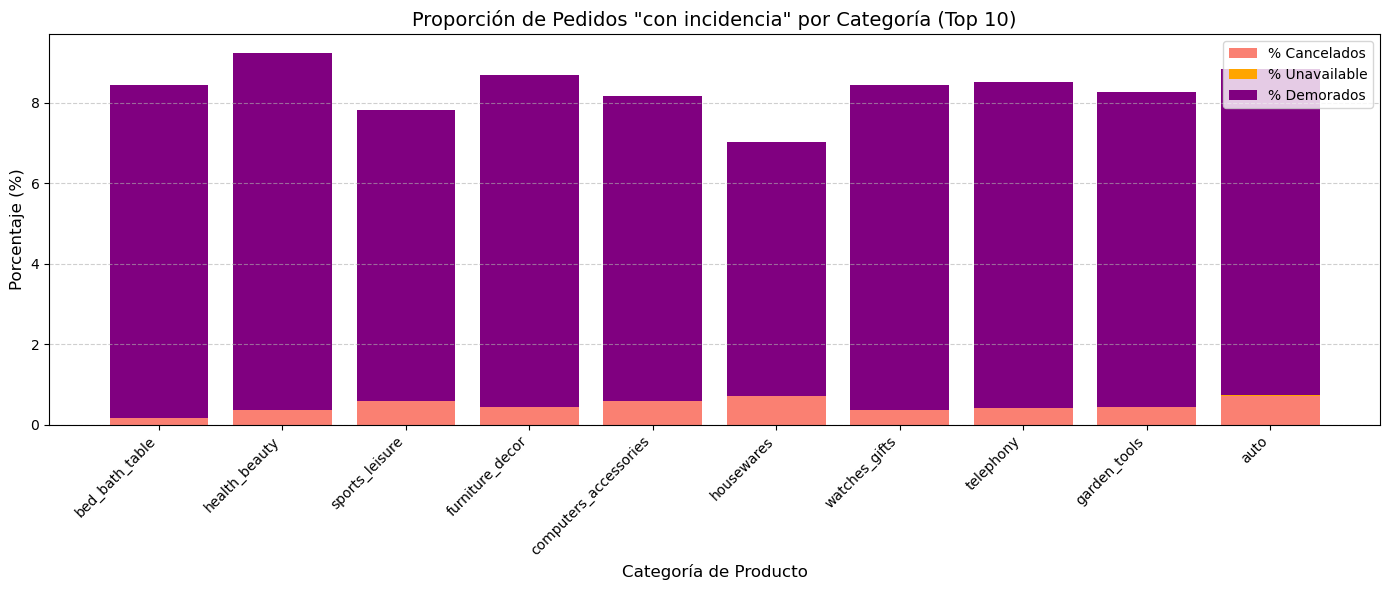

In [71]:
# Visualizamos las 10 categorías con más pedidos y su proporción de incidencias (cancelados, unavailable y demorados)
top10 = df_summary.head(10)

# Crear gráfico de barras apiladas
plt.figure(figsize=(14, 6))
plt.bar(top10['product_category_name_english'], top10['%_canceled'], label='% Cancelados', color='salmon')
plt.bar(top10['product_category_name_english'], top10['%_unavailable'],
        bottom=top10['%_canceled'], label='% Unavailable', color='orange')
plt.bar(top10['product_category_name_english'], top10['%_delayed'],
        bottom=top10['%_canceled'] + top10['%_unavailable'], label='% Demorados', color='purple')

# Etiquetas y formato
plt.title('Proporción de Pedidos "con incidencia" por Categoría (Top 10)', fontsize=14)
plt.xlabel('Categoría de Producto', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Evolución de las ventas

In [72]:
# Unimos las tablas de pedidos e items para relacionar cada producto con su pedido y estado correspondiente
df_orders_items = df_order_items.merge(
    df_orders_filtered[['order_id', 'order_purchase_timestamp', 'order_status']],
    on='order_id',
    how='inner'
)

In [73]:
# Filtramos solo los pedidos entregados y calculamos las ventas totales por mes a partir del precio de los productos
df_orders_items = df_orders_items[df_orders_items['order_status'] == 'delivered']

ventas_mensuales = (
    df_orders_items
    .set_index('order_purchase_timestamp')
    .resample('MS')['price']
    .sum()
    .reset_index(name='total_sales')
)

ventas_mensuales.head(25)

,order_purchase_timestamp,total_sales
0,2017-01-01,111798.36
1,2017-02-01,234223.40
2,2017-03-01,359198.85
3,2017-04-01,340669.68
4,2017-05-01,489338.25
5,2017-06-01,421923.37
6,2017-07-01,481604.52
7,2017-08-01,554699.70
8,2017-09-01,607399.67
9,2017-10-01,648247.65


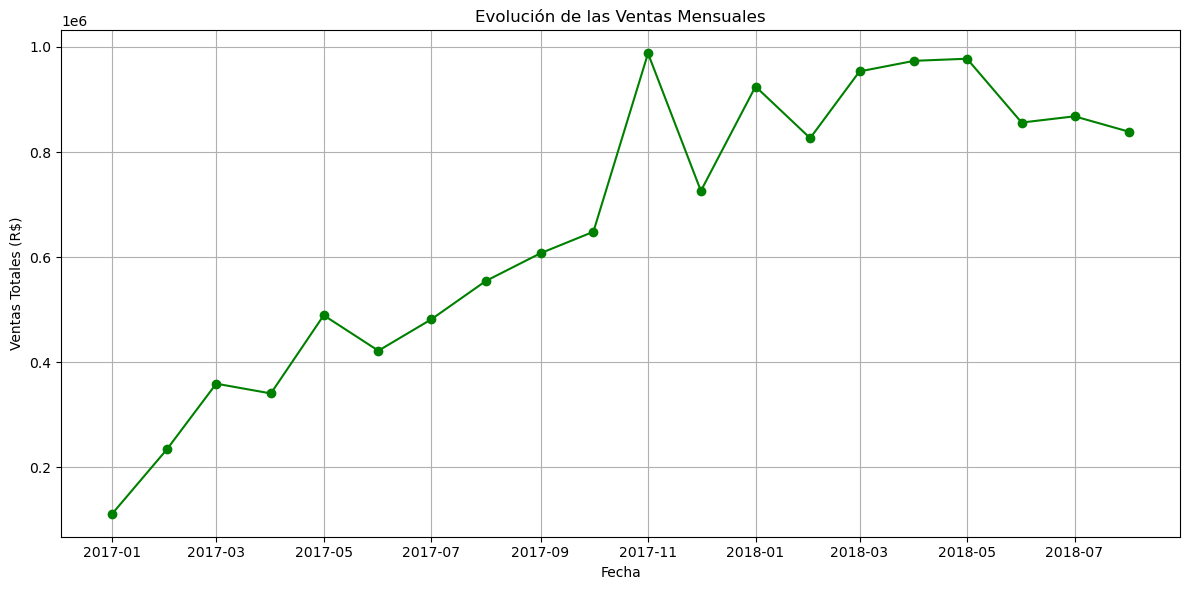

In [74]:
# Visualizamos la evolución de las ventas mensuales en un gráfico de líneas
plt.figure(figsize=(12, 6))
plt.plot(ventas_mensuales['order_purchase_timestamp'],
         ventas_mensuales['total_sales'],
         marker='o', color='green')
plt.title('Evolución de las Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales (R$)')
plt.grid()
plt.tight_layout()
plt.show()

### Comparativa mensual ventas 2017 vs 2018

In [75]:
# Añadimos columnas de año y mes para analizar la evolución temporal
ventas_mensuales['year'] = ventas_mensuales['order_purchase_timestamp'].dt.year
ventas_mensuales['month'] = ventas_mensuales['order_purchase_timestamp'].dt.month_name()

In [76]:
# Definimos el orden natural de los meses (en lugar del orden alfabético)
from pandas.api.types import CategoricalDtype

meses_orden = CategoricalDtype(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December'],
    ordered=True
)
ventas_mensuales['month'] = ventas_mensuales['month'].astype(meses_orden)

In [77]:
# Creamos una tabla dinámica para comparar las ventas mensuales por año
ventas_pivot = ventas_mensuales.pivot_table(
    index='month',
    columns='year',
    values='total_sales',
    aggfunc='sum'
).sort_index()

/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_83342/3163187394.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ventas_pivot = ventas_mensuales.pivot_table(


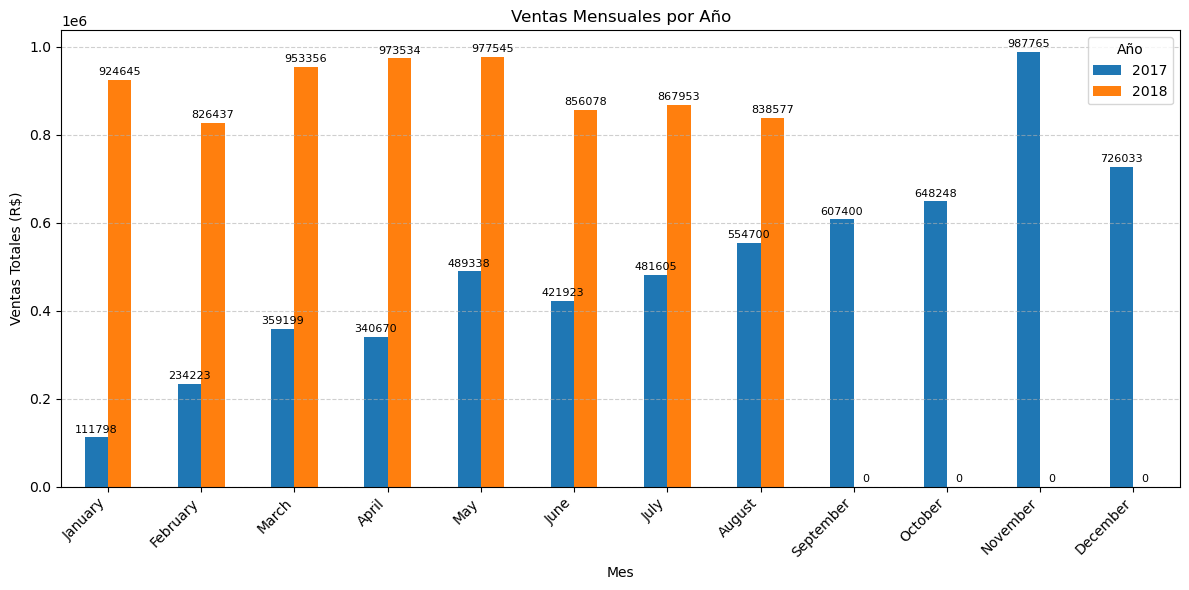

In [78]:
# Representamos las ventas mensuales por año en un gráfico de barras
ax = ventas_pivot.plot(kind='bar', figsize=(12, 6))

plt.title('Ventas Mensuales por Año')
plt.xlabel('Mes')
plt.ylabel('Ventas Totales (R$)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Año')

# Añadimos etiquetas con los valores sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8, padding=2)

plt.tight_layout()
plt.show()